In [ ]:
import logging

import torch

import specter
from specter.config import load_config
from specter.image import normalize_particles
from specter.imagegenerator import ImageGenerator
from specter.pdb import PDB
from specter.plots import plot3d, plot_particle_stack
from specter.potential import PotentialBuilder
from specter.progress import track
from specter.cryosparc import extract_parameters_from_csfile
from specter.ice import IceBank

import mrcfile

%load_ext autoreload
%autoreload 2

In [2]:
specter.set_verbosity(logging.INFO)

## Load config

All of the parameters that control the simulation (except those supplied by the .cs file — pixel size, energy, alpha, defocus, translations) live in [`simulate-particles-from-csfile.toml`](./simulate-particles-from-csfile.toml), loaded below via `load_config(...)` — **edit that file, not this notebook**, to change what gets generated.

In [ ]:
config = load_config("simulate-particles-from-csfile.toml")

## Specify .cs from CryoSPARC Job that contains rotations and aberrations

In [ ]:
n_particles = config.n_particles  # set to None for all.
(
    energy_kev,
    pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
    split,
) = extract_parameters_from_csfile(config.cs_path, n_particles=n_particles)
rotations.shape

## Generate particle scattering potential

In [ ]:
# fetch pdb file
# config.assembly: True fetches assembly, False fetches subunit, int fetches a specific assembly #
pdb = PDB(config.pdb_code, assembly=config.assembly, savefolder=config.pdb_savefolder)
# pdb = PDB(
#     "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# )

In [ ]:
# Samples 3D scattering potential onto specified grid
# Potential-building always runs on CPU, independent of config.device.
pb = PotentialBuilder(config.num_pixels, pixel_size.item(), pdb.atomic_numbers)

In [8]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

Building element ...:   0%|          | 0/4 [00:00<?, ?it/s]

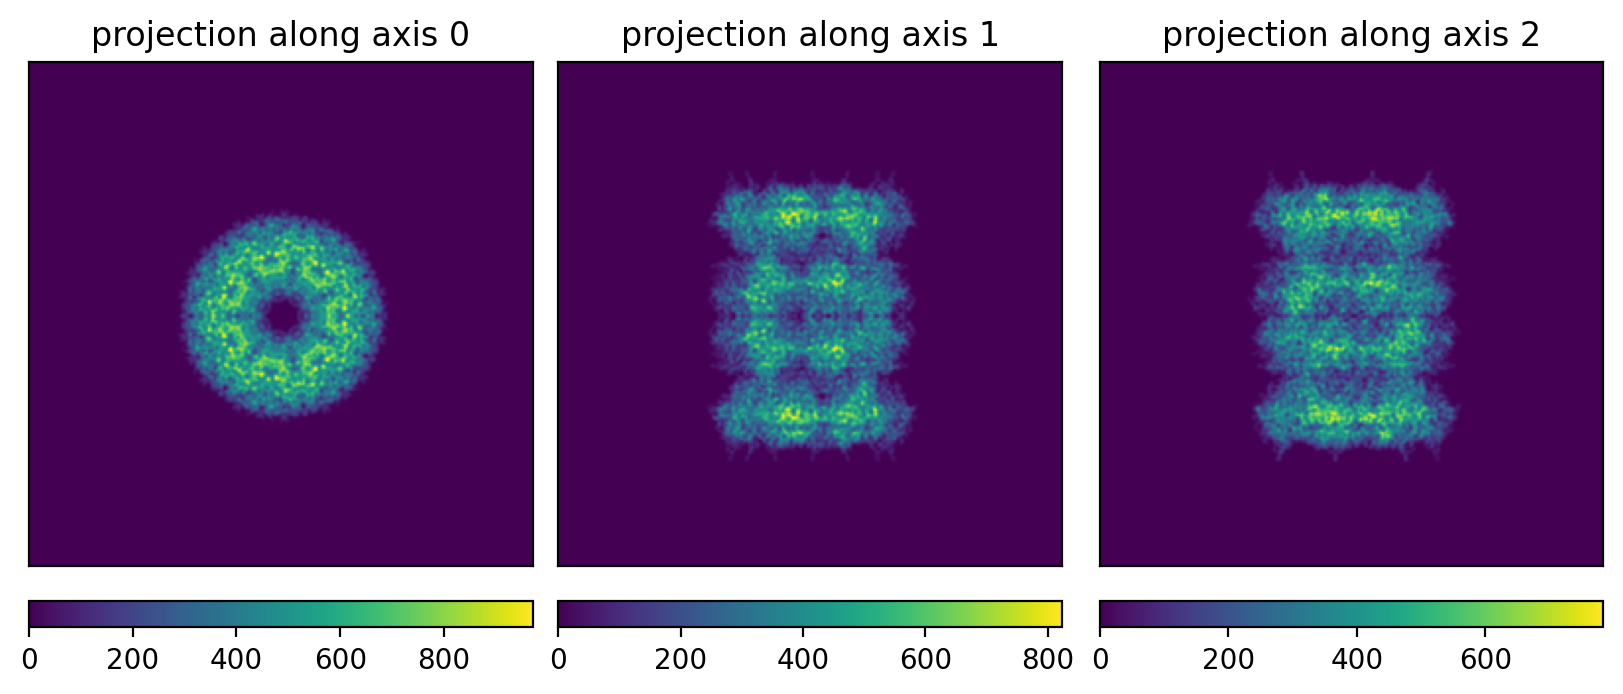

In [9]:
plot3d(V)

## Generate particles
Note: adjust ```coincidence_radius``` to match the contrast of your simulated images to the experiments.

In [ ]:
# n_particles = len(rotations)  # number of particles
device = config.device  # choose cpu if you run out of cuda memory.

In [ ]:
# Build the bank once — move to GPU before building
# method:
#   'random' : fast, worst accuracy
#   'ap'     : alternating projection. moderate speed, low accuracy
#   'gd'     : gradient descent. slow, highest accuracy
#   'mcmc'   : monte carlo markov chain. slowest, medium accuracy, under development.
#   None     : disable ice
ice_model = None if config.ice_model == "none" else config.ice_model
icecube_size = (
    config.icecube_size
    if config.icecube_size is not None
    else min(config.num_pixels, int(256 / pixel_size.item()))
)
bank = IceBank(
    dx=pixel_size.item(),
    n=icecube_size,
    method=ice_model,
    num_unique=config.num_unique_icecubes,
    build_batch_size=config.ice_build_batch_size,
).to(device)
bank.build()

In [ ]:
noise_model = None if config.noise_model == "none" else config.noise_model
detector_model = None if config.detector_model == "none" else config.detector_model

# Coincidence radius in pixels.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius = config.coincidence_radius_min

crowd_min_distance = (
    config.crowd_min_distance
    if config.crowd_min_distance is not None
    else pdb.max_diameter
)

num_frames = (
    config.num_frames if config.num_frames is not None else int(config.dose_min)
)

cc_angstrom = config.cc * 1e7 if config.cc is not None else None  # mm -> Å

model = ImageGenerator(
    V,
    pixel_size.item(),
    rotations,
    translations_A,
    ctf_params,
    energy_kev,
    config.dose_min,
    ice_thickness=config.ice_thickness,
    scattering_model=config.scattering_model,
    aberration_model=config.aberration_model,
    noise_model=noise_model,
    klim=None,
    ews_curvature_sign="positive",
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=config.crowd_max_distance_z,
    pad_fft=config.pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    icemaker=bank,
    bfactor=config.bfactor,
    convergence_angle=config.convergence_angle,
    cc=cc_angstrom,
    energy_spread=config.energy_spread,
    deltaV_V=config.deltaV_V,
    deltaI_I=config.deltaI_I,
    dose_envelope=config.dose_envelope,
).to(device)

In [ ]:
idx = torch.arange(len(rotations))
images = []
with torch.no_grad():
    for i in track(
        range(0, len(rotations), config.batchsize), description="Generating images"
    ):
        image = model(idx[i : i + config.batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

In [ ]:
# normalize and flip sign
if config.normalize_particles:
    particles, means, stds = normalize_particles(images)
    particles = -particles
else:
    particles = images

plot_particle_stack(particles, pixel_size)

## Compare with experimental particles (if available)

In [31]:
with mrcfile.mmap(
    "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/restack/batch_0_restacked.mrc"
) as mrc:
    exp = torch.as_tensor(mrc.data[indices].copy())

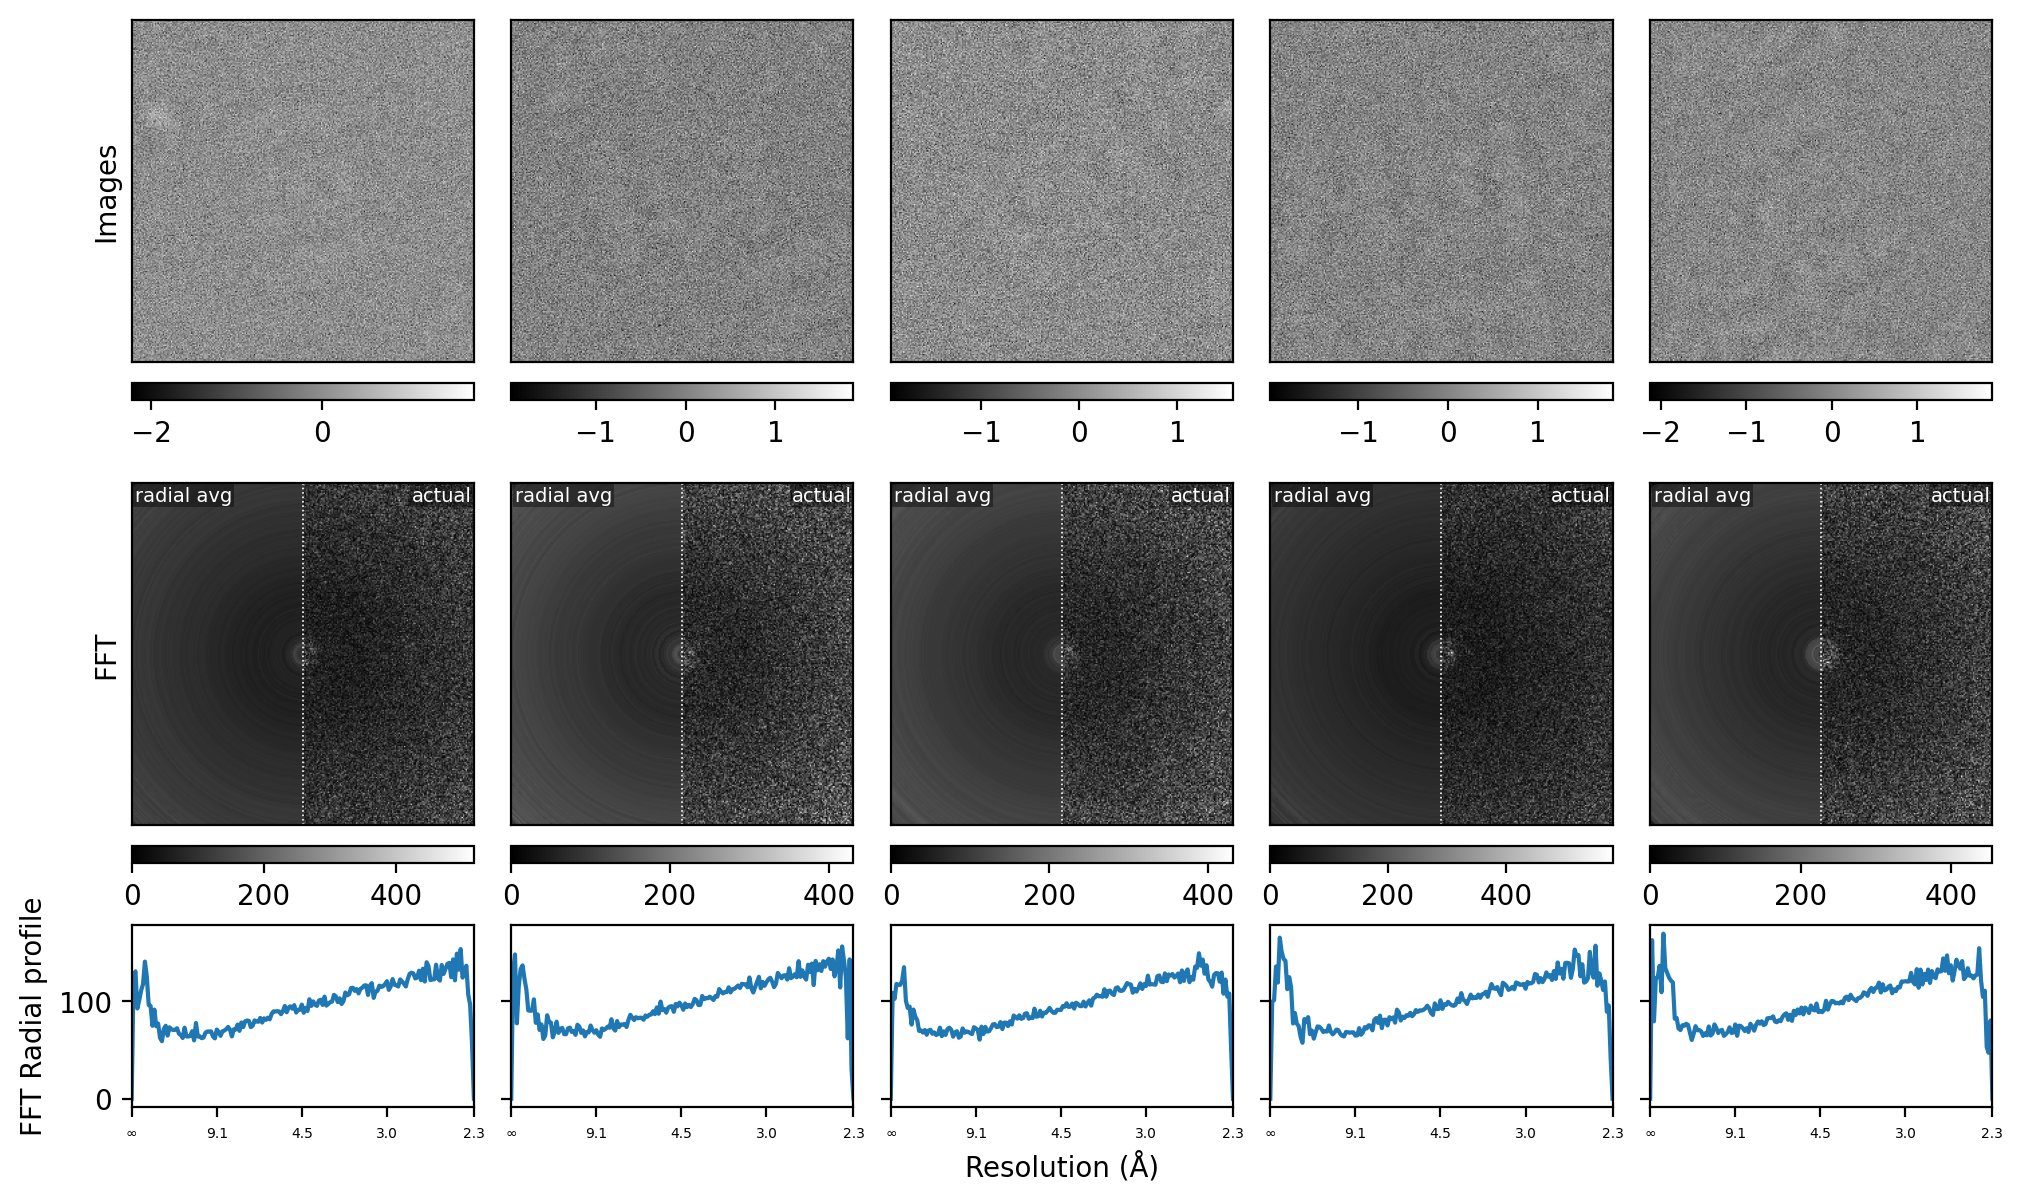

In [35]:
plot_particle_stack(exp, pixel_size)